Comparing feature selection methods for clustering

In [1]:
import polars as pl
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist
import joblib
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

In [3]:
# Load feature matrix
df_features = pl.read_parquet('../data/processed/ucl_features_final.parquet')
print(f"Loaded features: {df_features.shape}")

# Separate _index from features (don't use in analysis)
feature_columns = [c for c in df_features.columns if c != '_index']
X_all = df_features.select(feature_columns).to_numpy()
feature_names = feature_columns

print(f"Features for analysis: {X_all.shape}")
print(f"  (Excluding _index column)")

Loaded features: (503, 45)
Features for analysis: (503, 44)
  (Excluding _index column)


# FEATURE SELECTION - METHOD PREPARATION

In [4]:
def remove_collinear_features(X, feature_names, threshold=0.75):
    """
    Remove minimum number of features to ensure all pairwise correlations < threshold.
    Algorithm from Kuhn & Johnson (2013), Applied Predictive Modeling, p. 47.
    """
    features_remaining = list(feature_names)
    X_remaining = X.copy()
    features_removed = []

    while True:
        corr_matrix = np.corrcoef(X_remaining.T)
        upper_triangle = np.triu(np.abs(corr_matrix), k=1)
        max_corr = upper_triangle.max()

        if max_corr < threshold:
            break

        max_idx = np.where(upper_triangle == max_corr)
        i, j = max_idx[0][0], max_idx[1][0]

        avg_corr_i = np.mean(np.abs(corr_matrix[i, :]))
        avg_corr_j = np.mean(np.abs(corr_matrix[j, :]))

        remove_idx = i if avg_corr_i > avg_corr_j else j

        features_removed.append(features_remaining[remove_idx])
        features_remaining.pop(remove_idx)
        X_remaining = np.delete(X_remaining, remove_idx, axis=1)

    return X_remaining, features_remaining, features_removed

X_corr_filtered, features_after_corr_filter, features_dropped = remove_collinear_features(
    X_all, feature_names, threshold=0.75
)

print(f"Correlation filter: {len(features_dropped)} features dropped, {len(features_after_corr_filter)} remaining")
print(f"Removed: {', '.join(features_dropped)}")

Correlation filter: 14 features dropped, 30 remaining
Removed: log_h_index_scaled, log_total_citations_scaled, log_publication_count_scaled, log_max_citations_scaled, log_annual_impact_scaled, log_has_doi_count_scaled, log_journal_article_count_scaled, log_max_coauthors_scaled, has_teaching_experience, has_publications, log_career_years_scaled, log_i10_index_scaled, log_productivity_rate_scaled, log_avg_citations_per_publication_scaled


## Method 1: Correlation Filter

Collinearity between predictors introduces redundancy that adds model complexity without providing additional information. In distance-based clustering, correlated features give disproportionate weight to the same underlying signal, as each correlated variable contributes to distance calculations independently despite measuring similar constructs (Kuhn & Johnson, 2013, p. 46). Removing collinear features reduces this redundancy whilst preserving the minimum set of predictors necessary to represent the feature space.

The correlation filter implements a greedy algorithm that removes the minimum number of features to ensure all pairwise correlations fall below a specified threshold (Kuhn & Johnson, 2013, p. 47). The algorithm iteratively identifies the pair of predictors with the largest absolute correlation, calculates the average correlation of each with all other features, and removes the predictor with the higher average correlation. This process repeats until all pairwise correlations are below the threshold. By removing predictors with the most extensive correlation networks first, the algorithm minimises the total number of features dropped whilst eliminating multicollinearity.

A threshold of 0.75 is applied following the recommendation of Kuhn and Johnson (2013, p. 47) for models particularly sensitive to between-predictor correlations. Distance-based clustering algorithms fall into this category as they rely on distance metrics that can be distorted by redundant features representing the same underlying construct. The threshold represents a balance between removing problematic collinearity and retaining sufficient feature diversity.

The method uses Pearson correlation to assess pairwise relationships across all features. Whilst Pearson correlation is designed for continuous variables, it is applied here to a mixed feature set including scaled continuous variables, binary indicators, ordinal rankings, and bounded ratios. For binary features, Pearson correlation reduces to the phi coefficient, which is mathematically equivalent and valid. The application to ordinal and ratio features represents a pragmatic approximation, as computing different correlation types for different feature pairs would substantially increase implementation complexity. This limitation should be noted, as Pearson correlation may not fully capture monotonic relationships in ordinal data where Spearman rank correlation would be more appropriate.

Applying the correlation filter to the 44-feature dataset results in the removal of 14 features, leaving 30 features for subsequent analysis. The removed features include log_h_index_scaled, log_total_citations_scaled, log_publication_count_scaled, log_max_citations_scaled, log_annual_impact_scaled, log_has_doi_count_scaled, log_journal_article_count_scaled, log_max_coauthors_scaled, has_teaching_experience, has_publications, log_career_years_scaled, log_i10_index_scaled, log_productivity_rate_scaled, and log_avg_citations_per_publication_scaled. The removal of both binary engagement flags (has_teaching_experience, has_publications) alongside scaled bibliometric features indicates correlation between publication status and derived productivity metrics, whilst the substantial reduction in citation and publication count variants addresses the overlapping nature of these measures in the bibliometric data.

In [5]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_all)

print(f"Original features: {X_all.shape[1]}")
print(f"Components retained: {X_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

Original features: 44
Components retained: 13
Variance explained: 95.3%


Top Feature Loadings for All Components:
PC1 (63.3% variance):
  +0.259 × log_publication_count_scaled
  +0.259 × log_has_doi_count_scaled
  +0.258 × log_total_citations_scaled
  +0.258 × log_h_index_scaled
  +0.253 × log_annual_impact_scaled
PC2 (6.8% variance):
  +0.589 × log_years_since_last_pub_scaled
  +0.368 × log_avg_coauthors_scaled
  -0.328 × seniority_level
  -0.292 × log_solo_publications_scaled
  -0.250 × log_preprint_count_scaled
PC3 (5.8% variance):
  +0.450 × seniority_level
  -0.412 × log_recent_publications_scaled
  -0.390 × log_preprint_count_scaled
  +0.330 × log_years_since_last_pub_scaled
  -0.245 × log_avg_coauthors_scaled
PC4 (4.8% variance):
  +0.931 × log_teaching_module_count_scaled
  +0.213 × has_teaching_experience
  -0.119 × log_m_quotient_scaled
  +0.100 × log_years_since_last_pub_scaled
  -0.096 × log_preprint_count_scaled
PC5 (3.5% variance):
  +0.430 × log_years_since_last_pub_scaled
  +0.409 × log_solo_publications_scaled
  -0.320 × log_m_quotient_scal

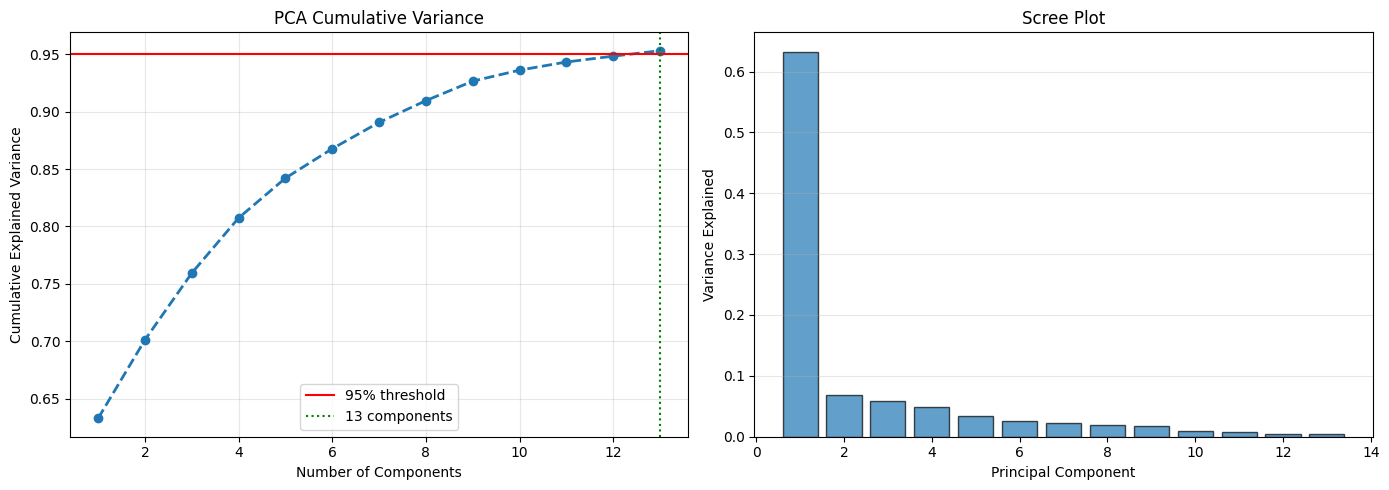

In [6]:
print("Top Feature Loadings for All Components:")
for i in range(X_pca.shape[1]):
    loadings = pca.components_[i]
    top_indices = np.argsort(np.abs(loadings))[::-1][:5]

    print(f"PC{i+1} ({pca.explained_variance_ratio_[i]:.1%} variance):")
    for idx in top_indices:
        direction = "+" if loadings[idx] > 0 else "-"
        print(f"  {direction}{abs(loadings[idx]):.3f} × {feature_names[idx]}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cumsum = np.cumsum(pca.explained_variance_ratio_)
ax1.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='--', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='-', label='95% threshold')
ax1.axvline(x=len(cumsum), color='g', linestyle=':', label=f'{len(cumsum)} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title('PCA Cumulative Variance')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_,
        alpha=0.7,
        edgecolor='black')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained')
ax2.set_title('Scree Plot')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Method 2: Principal Component Analysis

Principal component analysis reduces dimensionality by transforming correlated features into orthogonal components that capture maximum variance. This method provides an alternative to correlation filtering by eliminating multicollinearity through linear transformation rather than feature removal, whilst preserving information content through variance retention.

A threshold of 95% cumulative explained variance was selected for component retention. Whilst Jolliffe (2002) recommends thresholds of 70-90% for typical applications, he notes that values exceeding 90% are appropriate when one or two principal components represent very dominant sources of variation and less obvious structures beyond these are of analytical interest. The variance decomposition reveals that the first principal component accounts for 63.3% of total variance, representing a dominant bibliometric productivity signal. The scree plot demonstrates this dominance visually, with PC1 substantially exceeding subsequent components. Following Jolliffe's guidance for such cases, the 95% threshold ensures retention of secondary patterns in collaboration behaviour, teaching engagement, and temporal activity that may distinguish academic subgroups beyond raw productivity differences.

The analysis reduces the 44-feature space to 13 principal components explaining 95.3% of cumulative variance. The first component (63.3% variance) represents overall bibliometric productivity, with strong positive loadings on publication counts, citation metrics, h-index, and annual impact. This component captures the dominant dimension along which academics vary in research output and influence. The second component (6.8% variance) contrasts publication recency and collaboration patterns against seniority, with positive loadings on years since last publication and average coauthors, and negative loadings on seniority level and solo publications. This component distinguishes recently active collaborative researchers from senior academics with historical publication records.

The third component (5.8% variance) captures a seniority-recency trade-off, loading positively on seniority level and years since last publication whilst loading negatively on recent publications and preprints. The fourth component (4.8% variance) isolates teaching engagement through a dominant loading on teaching module count. The fifth component (3.5% variance) reflects publication independence and temporal patterns, with positive loadings on years since last publication and solo work rate, and negative loadings on normalised impact metrics. The sixth component (2.6% variance) contrasts solo publication behaviour against seniority and preprint activity.

Components seven through thirteen capture progressively more specific patterns, each explaining less than 2.5% of variance individually but collectively contributing 9.0% of total variance. PC7 distinguishes preprint users from those with complete profiles and ML/AI focus. PC8 captures the interaction between profile completeness, preprint activity, and research domain. PC9 reflects productivity efficiency relative to career length. PC10 through PC13 capture nuanced patterns in collaboration networks, publication venue preferences, domain specialisations, and profile completion behaviours. Whilst individually minor, these components preserve subtle distinctions that may be relevant for identifying niche academic subgroups.

The orthogonality of principal components eliminates multicollinearity by construction, as components are uncorrelated by definition. This property ensures equal contribution of all components to distance calculations in clustering algorithms, avoiding the redundancy issues that motivated the correlation filtering approach. However, this advantage comes at the cost of interpretability, as components represent linear combinations of original features rather than directly measurable quantities. The loading patterns provide insight into component meaning but do not enable straightforward attribution of cluster characteristics to specific original features.

In [7]:
def hopkins_statistic(X, n_samples=None):
    """
    Hopkins statistic for clustering tendency.
    Tests whether data has non-random structure suitable for clustering.

    Reference: Banerjee, A., & Dave, R. N. (2004). Validating clusters using
    the Hopkins statistic. Proceedings of the 2004 IEEE International
    Conference on Fuzzy Systems, 1, 149-153.

    Interpretation (Banerjee & Dave, 2004, p. 150):
    H ≈ 0.7-0.99: Highly clusterable (non-random structure)
    H ≈ 0.5: Random (uniformly distributed)
    H ≈ 0.01-0.3: Regularly spaced
    """
    n, d = X.shape

    if n_samples is None:
        n_samples = min(int(0.1 * n), 200)

    sample_indices = np.random.choice(n, n_samples, replace=False)
    X_sample = X[sample_indices]

    X_min, X_max = X.min(axis=0), X.max(axis=0)
    X_random = np.random.uniform(X_min, X_max, (n_samples, d))

    nn_real = NearestNeighbors(n_neighbors=1).fit(X)
    u_distances, _ = nn_real.kneighbors(X_random)
    U = u_distances.sum()

    nn_sample = NearestNeighbors(n_neighbors=2).fit(X)
    w_distances, _ = nn_sample.kneighbors(X_sample)
    W = w_distances[:, 1].sum()

    if U + W == 0:
        return 0.5

    return U / (U + W)

In [8]:
methods = {
    'Correlation Filter (r<0.75)': X_corr_filtered,
    'PCA (95% variance)': X_pca
}

results = []

for method_name, X_method in methods.items():
    print(f"\n{method_name}")
    print(f"Features: {X_method.shape[1]}")

    result = {'Method': method_name, 'Features': X_method.shape[1]}

    hopkins = hopkins_statistic(X_method)
    result['Hopkins'] = hopkins
    result['Tendency'] = "High" if hopkins > 0.7 else "Moderate" if hopkins > 0.5 else "Low"
    print(f"Hopkins: {hopkins:.3f} ({result['Tendency']} clusterability)")

    condition = np.linalg.cond(X_method)
    result['Condition'] = condition
    result['Stability'] = "Excellent" if condition < 10 else "Good" if condition < 30 else "Poor"
    print(f"Condition number: {condition:.2f} ({result['Stability']} stability)")

    if 'PCA' in method_name:
        max_corr = 0.0
        print(f"Max correlation: 0.000 (orthogonal by design)")
    else:
        corr = np.corrcoef(X_method.T)
        max_corr = np.max(np.abs(corr[np.triu_indices_from(corr, k=1)]))
        print(f"Max correlation: {max_corr:.3f}")
    result['Max Corr'] = max_corr

    distances = pdist(X_method, metric='euclidean')
    result['Dist Variance'] = np.var(distances)
    print(f"Distance variance: {result['Dist Variance']:.3f}")

    results.append(result)

df_results = pl.DataFrame(results)
df_results


Correlation Filter (r<0.75)
Features: 30
Hopkins: 0.762 (High clusterability)
Condition number: 31.04 (Poor stability)
Max correlation: 0.716
Distance variance: 2.137

PCA (95% variance)
Features: 13
Hopkins: 0.784 (High clusterability)
Condition number: 11.55 (Good stability)
Max correlation: 0.000 (orthogonal by design)
Distance variance: 6.924


Method,Features,Hopkins,Tendency,Condition,Stability,Max Corr,Dist Variance
str,i64,f64,str,f64,str,f64,f64
"""Correlation Filter (r<0.75)""",30,0.761924,"""High""",31.040364,"""Poor""",0.715629,2.136598
"""PCA (95% variance)""",13,0.783726,"""High""",11.545495,"""Good""",0.0,6.924241


## Method Comparison and Selection

The correlation filter and principal component analysis represent alternative strategies for feature space preparation, each with distinct trade-offs between interpretability and mathematical properties. Both methods were evaluated using quantitative metrics to determine which approach provides superior conditions for distance-based clustering algorithms.

The Hopkins statistic assesses clustering tendency by testing whether data exhibit non-random structure suitable for partitioning (Banerjee & Dave, 2004). The statistic compares nearest-neighbour distances from randomly sampled locations to those between actual data points. Under random distribution, these distances should be equivalent (H ≈ 0.5), whilst clustered data produce larger sampling-to-pattern distances relative to pattern-to-pattern distances (H ≈ 0.7-0.99). Both feature selection methods demonstrate high clustering tendency, with the correlation filter achieving H = 0.762 and PCA achieving H = 0.784. These values fall within Banerjee and Dave's (2004, p. 150) range for highly clusterable data, indicating that both approaches preserve the non-random structure necessary for meaningful clustering.

The condition number measures numerical stability in matrix computations, quantifying how sensitive results are to small perturbations or rounding errors in calculations. Lower condition numbers indicate well-conditioned problems where small input errors produce proportionally small output errors, whilst higher values suggest potential numerical instability. PCA exhibits superior numerical stability with a condition number of 11.55 compared to 31.04 for the correlation filter. This difference has practical implications for distance-based clustering, as numerically unstable features can introduce spurious variation in distance calculations that may lead to unreliable cluster assignments.

Maximum pairwise correlation quantifies residual feature redundancy after dimensionality reduction. The correlation filter retains a maximum absolute correlation of 0.716 between features despite the 0.75 threshold, as the greedy removal algorithm cannot guarantee all correlations fall strictly below the cutoff when multiple correlated groups exist. PCA achieves perfect orthogonality (r = 0.0) by construction, as principal components are mathematically constrained to be uncorrelated. This complete elimination of redundancy ensures each component contributes independent information to distance calculations.

Distance variance measures the spread of pairwise Euclidean distances across all observation pairs, with higher variance indicating greater potential for separating observations into distinct groups. PCA produces substantially higher distance variance (6.92) compared to the correlation filter (2.14), representing a 3.24-fold increase in distributional spread. This enhanced variance suggests PCA creates a feature space with more pronounced differentiation between observations, potentially facilitating clearer cluster boundaries.

Principal component analysis is selected for clustering based on its superior performance across three of four evaluation metrics. Whilst both methods demonstrate comparable clustering tendency, PCA provides better numerical stability for reliable distance computations, eliminates feature redundancy entirely through orthogonal transformation, and produces greater distance variance indicating enhanced separability. The method achieves 57% dimensionality reduction (13 components from 44 features) whilst retaining 95.3% of original variance. This substantial compression reduces computational complexity in subsequent clustering whilst preserving the information content necessary for identifying meaningful academic subgroups. The primary limitation of PCA is reduced interpretability, as components represent linear combinations of original features rather than directly measurable quantities, complicating the attribution of cluster characteristics to specific academic behaviours.

---

**References:**

Banerjee, A., & Dave, R. N. (2004). Validating clusters using the Hopkins statistic. *Proceedings of the 2004 IEEE International Conference on Fuzzy Systems*, 1, 149-153.

Jolliffe, I. T. (2002). *Principal component analysis* (2nd ed.). Springer.

Kuhn, M., & Johnson, K. (2013). *Applied predictive modeling*. Springer.

In [9]:
df_pca_final = pl.DataFrame(
    X_pca,
    schema=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

index_values = df_features.select('_index').to_series()
df_pca_final = df_pca_final.with_columns([
    pl.Series('_index', index_values)
])

df_pca_final.write_parquet('../data/processed/ucl_pca_features.parquet')

print(f"Saved: ucl_pca_features.parquet ({df_pca_final.shape})")

Saved: ucl_pca_features.parquet ((503, 14))
